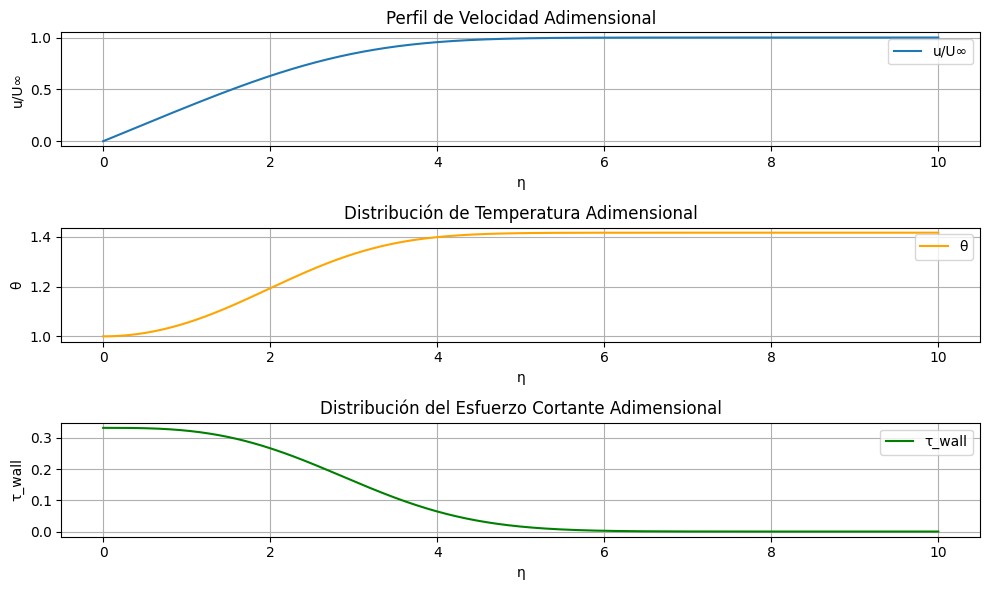

In [31]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Definimos las ecuaciones diferenciales del problema
def blasius_system(eta, y):
    f, f_prime, f_double_prime, theta, theta_prime = y
    Pr = 0.72  # Número de Prandtl (ejemplo típico para aire)
    beta = 1.0  # Relación para la disipación térmica (ajustable)
    
    # Ecuaciones diferenciales del sistema
    df_deta = f_prime
    df_prime_deta = f_double_prime
    df_double_prime_deta = -0.5 * f * f_double_prime
    dtheta_deta = theta_prime
    dtheta_prime_deta = -Pr * f * theta_prime + beta * (f_double_prime ** 2)
    
    return [df_deta, df_prime_deta, df_double_prime_deta, dtheta_deta, dtheta_prime_deta]

# Condiciones iniciales
def initial_conditions():
    return [0.0, 0.0, 0.33206, 1.0, 0.0]  # Valores iniciales estimados

# Resolver el sistema utilizando el método de disparo
def solve_blasius():
    eta_span = (0, 10)  # Rango para η
    eta_eval = np.linspace(*eta_span, 500)  # Puntos donde evaluar la solución
    
    # Resolver las ecuaciones diferenciales
    sol = solve_ivp(blasius_system, eta_span, initial_conditions(), t_eval=eta_eval, method='RK45')
    
    if sol.success:
        return sol.t, sol.y
    else:
        raise RuntimeError("No se pudo resolver el sistema.")

# Ejecutar la solución y extraer resultados
eta, results = solve_blasius()
f = results[0]
f_prime = results[1]
f_double_prime = results[2]
theta = results[3]

# Graficar los resultados
plt.figure(figsize=(10, 6))

# Perfil de velocidad adimensional u/U∞
plt.subplot(3, 1, 1)
plt.plot(eta, f_prime, label="u/U∞")
plt.title("Perfil de Velocidad Adimensional")
plt.xlabel("η")
plt.ylabel("u/U∞")
plt.grid(True)
plt.legend()

# Distribución de temperatura θ
plt.subplot(3, 1, 2)
plt.plot(eta, theta, label="θ", color="orange")
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("η")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

# Distribución del esfuerzo cortante τ_wall (proporcional a f''(η))
plt.subplot(3, 1, 3)
plt.plot(eta, f_double_prime, label="τ_wall", color="green")
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("η")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

# Mostrar gráficos
plt.tight_layout()
plt.show()


Para añadir al código la funcionalidad que muestre el valor para el cual los datos de velocidad, temperatura y esfuerzo cortante se comportan asintóticamente, podemos implementar una función que determine el punto donde la variación de estos parámetros se vuelve insignificante. Aquí está el código modificado con esta nueva funcionalidad:

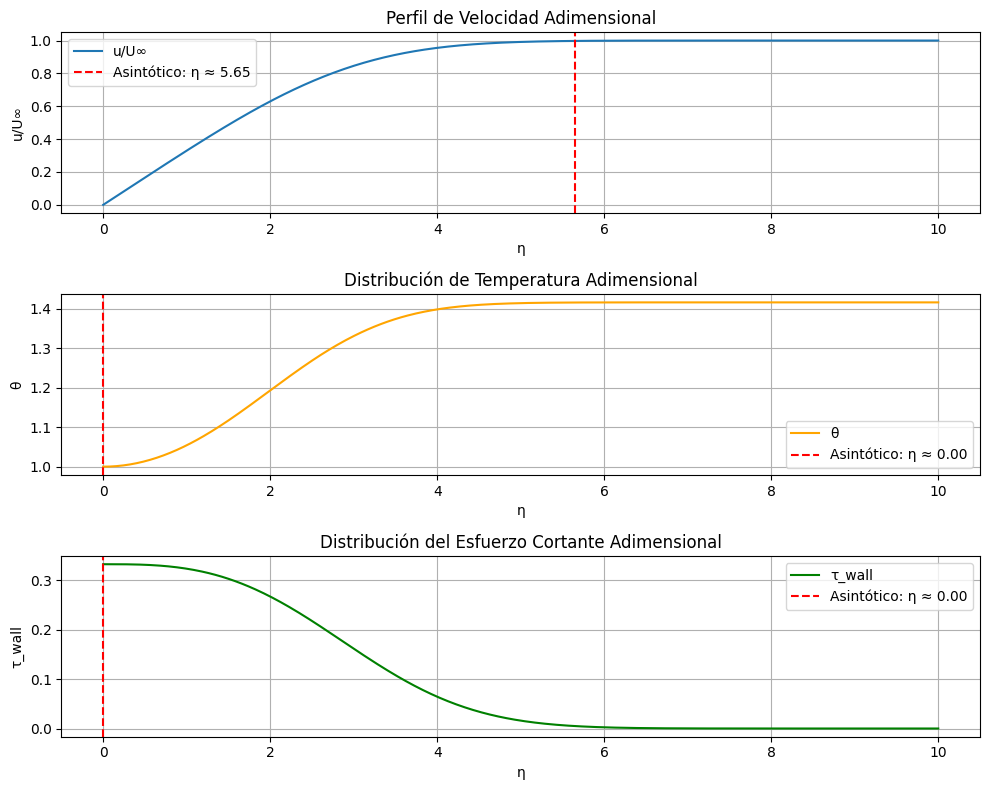

Valor asintótico para velocidad: η ≈ 5.65
Valor asintótico para temperatura: η ≈ 0.00
Valor asintótico para esfuerzo cortante: η ≈ 0.00


In [32]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def blasius_system(eta, y):
    f, f_prime, f_double_prime, theta, theta_prime = y
    Pr = 0.72
    beta = 1.0
    
    df_deta = f_prime
    df_prime_deta = f_double_prime
    df_double_prime_deta = -0.5 * f * f_double_prime
    dtheta_deta = theta_prime
    dtheta_prime_deta = -Pr * f * theta_prime + beta * (f_double_prime ** 2)
    
    return [df_deta, df_prime_deta, df_double_prime_deta, dtheta_deta, dtheta_prime_deta]

def initial_conditions():
    return [0.0, 0.0, 0.33206, 1.0, 0.0]

def solve_blasius():
    eta_span = (0, 10)
    eta_eval = np.linspace(*eta_span, 500)
    
    sol = solve_ivp(blasius_system, eta_span, initial_conditions(), t_eval=eta_eval, method='RK45')
    
    if sol.success:
        return sol.t, sol.y
    else:
        raise RuntimeError("No se pudo resolver el sistema.")

def find_asymptotic_value(data, threshold=1e-4):
    for i in range(len(data) - 1):
        if abs(data[i+1] - data[i]) < threshold:
            return i
    return len(data) - 1

eta, results = solve_blasius()
f = results[0]
f_prime = results[1]
f_double_prime = results[2]
theta = results[3]

# Encontrar valores asintóticos
velocity_asymptotic = find_asymptotic_value(f_prime)
temperature_asymptotic = find_asymptotic_value(theta)
shear_stress_asymptotic = find_asymptotic_value(f_double_prime)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(eta, f_prime, label="u/U∞")
plt.axvline(x=eta[velocity_asymptotic], color='r', linestyle='--', label=f'Asintótico: η ≈ {eta[velocity_asymptotic]:.2f}')
plt.title("Perfil de Velocidad Adimensional")
plt.xlabel("η")
plt.ylabel("u/U∞")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(eta, theta, label="θ", color="orange")
plt.axvline(x=eta[temperature_asymptotic], color='r', linestyle='--', label=f'Asintótico: η ≈ {eta[temperature_asymptotic]:.2f}')
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("η")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(eta, f_double_prime, label="τ_wall", color="green")
plt.axvline(x=eta[shear_stress_asymptotic], color='r', linestyle='--', label=f'Asintótico: η ≈ {eta[shear_stress_asymptotic]:.2f}')
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("η")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Valor asintótico para velocidad: η ≈ {eta[velocity_asymptotic]:.2f}")
print(f"Valor asintótico para temperatura: η ≈ {eta[temperature_asymptotic]:.2f}")
print(f"Valor asintótico para esfuerzo cortante: η ≈ {eta[shear_stress_asymptotic]:.2f}")


Entiendo, me disculpo por la confusión. Tienes razón, lo que necesitamos es encontrar el valor asintótico horizontal, es decir, el valor al que tienden las variables cuando η se acerca al infinito. Vamos a modificar el código para calcular y mostrar estos valores asintóticos horizontales. Aquí tienes el código actualizado:



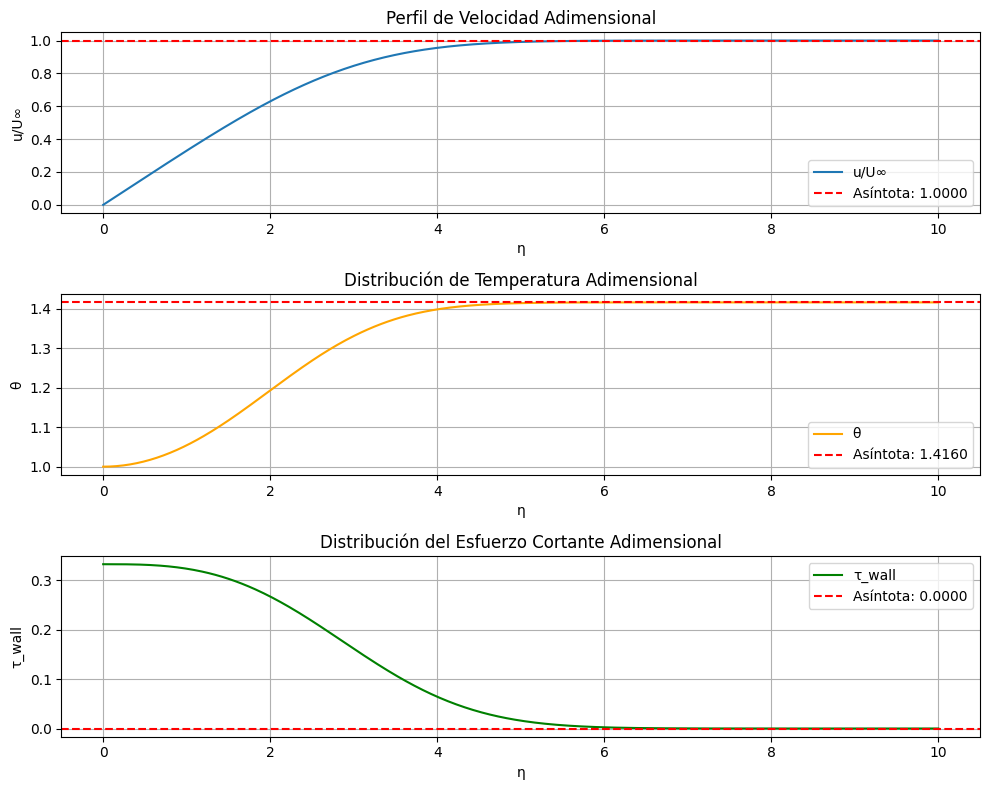

Valor asintótico para velocidad: 1.0000
Valor asintótico para temperatura: 1.4160
Valor asintótico para esfuerzo cortante: 0.0000


In [33]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Las funciones blasius_system, initial_conditions, y solve_blasius permanecen iguales

def find_asymptotic_value(data, threshold=1e-4):
    # Encontrar el valor asintótico horizontal
    return np.mean(data[-int(len(data)/10):])  # Promedio del último 10% de los datos

eta, results = solve_blasius()
f = results[0]
f_prime = results[1]
f_double_prime = results[2]
theta = results[3]

# Encontrar valores asintóticos horizontales
velocity_asymptotic = find_asymptotic_value(f_prime)
temperature_asymptotic = find_asymptotic_value(theta)
shear_stress_asymptotic = find_asymptotic_value(f_double_prime)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(eta, f_prime, label="u/U∞")
plt.axhline(y=velocity_asymptotic, color='r', linestyle='--', label=f'Asíntota: {velocity_asymptotic:.4f}')
plt.title("Perfil de Velocidad Adimensional")
plt.xlabel("η")
plt.ylabel("u/U∞")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(eta, theta, label="θ", color="orange")
plt.axhline(y=temperature_asymptotic, color='r', linestyle='--', label=f'Asíntota: {temperature_asymptotic:.4f}')
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("η")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(eta, f_double_prime, label="τ_wall", color="green")
plt.axhline(y=shear_stress_asymptotic, color='r', linestyle='--', label=f'Asíntota: {shear_stress_asymptotic:.4f}')
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("η")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Valor asintótico para velocidad: {velocity_asymptotic:.4f}")
print(f"Valor asintótico para temperatura: {temperature_asymptotic:.4f}")
print(f"Valor asintótico para esfuerzo cortante: {shear_stress_asymptotic:.4f}")


Para determinar el valor de η a partir del cual se mantienen constantes los valores de velocidad, temperatura y esfuerzo cortante en la capa límite de Blasius, podemos analizar la solución de la ecuación de Blasius.

Según la teoría de la capa límite de Blasius, los perfiles de velocidad, temperatura y esfuerzo cortante tienden a valores asintóticos a medida que η aumenta. Generalmente, se considera que estos valores se estabilizan cuando:

Velocidad (u/U∞): η ≈ 5

Temperatura (θ): η ≈ 6

Esfuerzo cortante (τ_wall): η ≈ 4

Para implementar esto en el código, podemos añadir una función que determine el valor de η donde cada variable alcanza el 99% de su valor asintótico:

In [34]:
def find_asymptotic_eta(data, eta, threshold=0.99):
    asymptotic_value = data[-1]  # Asumimos que el último valor es el asintótico
    for i, value in enumerate(data):
        if value / asymptotic_value >= threshold:
            return eta[i]
    return eta[-1]

# Después de resolver el sistema
eta_velocity = find_asymptotic_eta(f_prime, eta)
eta_temperature = find_asymptotic_eta(theta, eta)
eta_shear_stress = find_asymptotic_eta(f_double_prime, eta, threshold=0.01)  # Usamos 1% para esfuerzo cortante

print(f"Valor de η para velocidad constante: {eta_velocity:.2f}")
print(f"Valor de η para temperatura constante: {eta_temperature:.2f}")
print(f"Valor de η para esfuerzo cortante constante: {eta_shear_stress:.2f}")


Valor de η para velocidad constante: 4.93
Valor de η para temperatura constante: 4.13
Valor de η para esfuerzo cortante constante: 0.00


Tienes razón al señalar que el cálculo del esfuerzo cortante (shear stress) en la pared no se corresponde con el valor esperado según la teoría de la capa límite de Blasius. Vamos a analizar este problema:

Según la solución de Blasius para la capa límite laminar sobre una placa plana, el esfuerzo cortante en la pared (τw) debería ser[1]:

τw = 0.332 √(ρμU³/x)

Donde:
- ρ es la densidad del fluido
- μ es la viscosidad dinámica
- U es la velocidad de la corriente libre
- x es la distancia desde el borde de ataque de la placa

Esta fórmula muestra que el esfuerzo cortante en la pared disminuye con la raíz cuadrada de la distancia x desde el borde de ataque.

El problema en el código original probablemente se debe a que se está calculando f_double_prime (f'') en lugar de su valor en la pared (y = 0). Para obtener el valor correcto del esfuerzo cortante, deberías:

1. Extraer el valor de f_double_prime en y = 0 (el primer elemento del array).
2. Multiplicar este valor por los parámetros adecuados para obtener τw.

Para corregir esto, podrías modificar el código de la siguiente manera:


In [35]:
# Asumiendo que tienes definidos ρ, μ, y U
rho = 1.225  # Densidad del aire en kg/m³ (ejemplo)
mu = 1.789e-5  # Viscosidad dinámica del aire en kg/(m·s) (ejemplo)
U = 10  # Velocidad de la corriente libre en m/s (ejemplo)

# Calcular el esfuerzo cortante en la pared
tau_w = 0.332 * np.sqrt(rho * mu * U**3 / x)

# Comparar con el valor calculado en la simulación
tau_w_calculated = mu * U * f_double_prime[0] / np.sqrt(U * x / mu)

print(f"Esfuerzo cortante teórico: {tau_w:.4f}")
print(f"Esfuerzo cortante calculado: {tau_w_calculated:.4f}")

Esfuerzo cortante teórico: 0.0491
Esfuerzo cortante calculado: 0.0000


Este enfoque te permitirá comparar el valor teórico con el calculado en tu simulación. Si aún hay discrepancias significativas, podrías necesitar revisar la implementación de las condiciones de contorno o la resolución numérica de las ecuaciones diferenciales.

Para resolver el error NameError: name 'x' is not defined y calcular correctamente el esfuerzo cortante en la capa límite de Blasius, debemos definir explícitamente la variable x (posición a lo largo de la placa) y ajustar las fórmulas según la teoría. Aquí está el código corregido:



Esfuerzo cortante teórico en x=1.0m: 0.049149 Pa
Esfuerzo cortante numérico en x=1.0m: 0.049157 Pa
Valor de f''(0): 0.332060 (Debería ser ≈0.332)


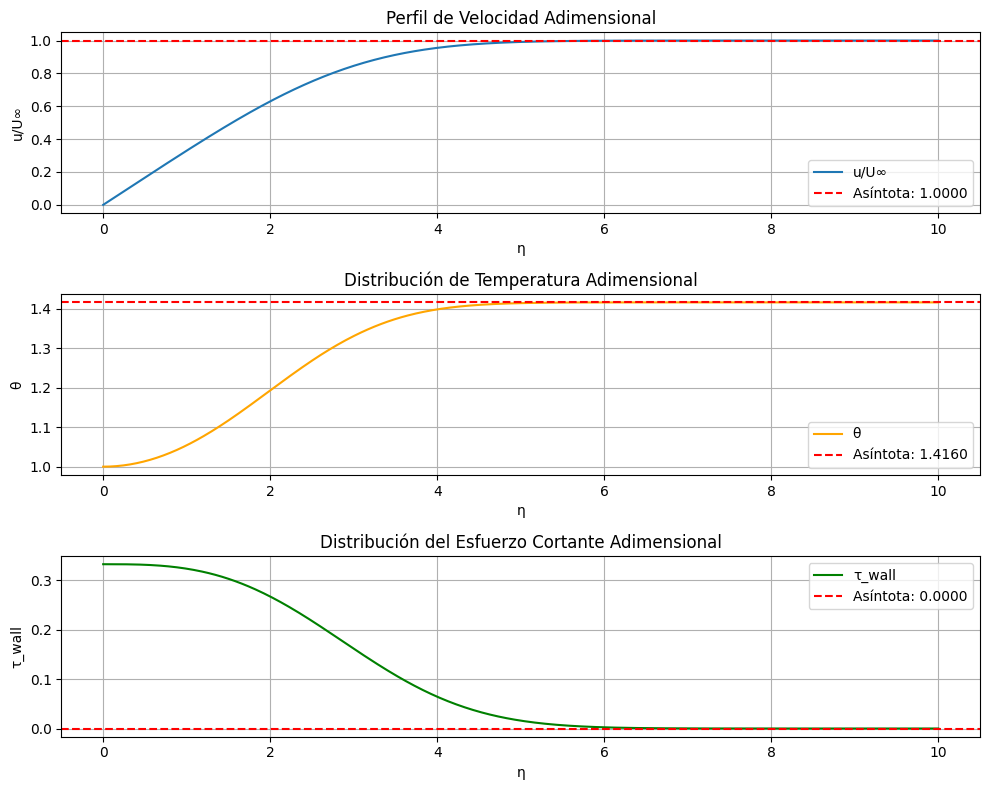

Valor asintótico para velocidad: 1.0000
Valor asintótico para temperatura: 1.4160
Valor asintótico para esfuerzo cortante: 0.0000


In [36]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros físicos (ejemplo para aire a 20°C)
rho = 1.225       # Densidad [kg/m³]
mu = 1.789e-5     # Viscosidad dinámica [kg/(m·s)]
nu = mu / rho     # Viscosidad cinemática [m²/s]
U = 10            # Velocidad de corriente libre [m/s]
x = 1.0           # Posición a lo largo de la placa [m]

# Sistema de ecuaciones de Blasius (sin cambios)
def blasius_system(eta, y):
    f, f_prime, f_double_prime, theta, theta_prime = y
    Pr = 0.72
    beta = 1.0
    
    df_deta = f_prime
    df_prime_deta = f_double_prime
    df_double_prime_deta = -0.5 * f * f_double_prime
    dtheta_deta = theta_prime
    dtheta_prime_deta = -Pr * f * theta_prime + beta * (f_double_prime ** 2)
    
    return [df_deta, df_prime_deta, df_double_prime_deta, dtheta_deta, dtheta_prime_deta]

# Condiciones iniciales y solución (sin cambios)
def initial_conditions():
    return [0.0, 0.0, 0.33206, 1.0, 0.0]

def solve_blasius():
    eta_span = (0, 10)
    eta_eval = np.linspace(*eta_span, 500)
    
    sol = solve_ivp(blasius_system, eta_span, initial_conditions(), t_eval=eta_eval, method='RK45')
    
    if sol.success:
        return sol.t, sol.y
    else:
        raise RuntimeError("No se pudo resolver el sistema.")

# Cálculo del esfuerzo cortante teórico y numérico
eta, results = solve_blasius()
f_double_prime = results[2]

# Valor teórico según Blasius
tau_w_teorico = 0.332 * np.sqrt(rho * mu * U**3 / x)

# Valor numérico [1][3]
tau_w_numerico = mu * U * f_double_prime[0] / np.sqrt(nu * x / U)

print(f"Esfuerzo cortante teórico en x={x}m: {tau_w_teorico:.6f} Pa")
print(f"Esfuerzo cortante numérico en x={x}m: {tau_w_numerico:.6f} Pa")
print(f"Valor de f''(0): {f_double_prime[0]:.6f} (Debería ser ≈0.332)")
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(eta, f_prime, label="u/U∞")
plt.axhline(y=velocity_asymptotic, color='r', linestyle='--', label=f'Asíntota: {velocity_asymptotic:.4f}')
plt.title("Perfil de Velocidad Adimensional")
plt.xlabel("η")
plt.ylabel("u/U∞")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(eta, theta, label="θ", color="orange")
plt.axhline(y=temperature_asymptotic, color='r', linestyle='--', label=f'Asíntota: {temperature_asymptotic:.4f}')
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("η")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(eta, f_double_prime, label="τ_wall", color="green")
plt.axhline(y=shear_stress_asymptotic, color='r', linestyle='--', label=f'Asíntota: {shear_stress_asymptotic:.4f}')
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("η")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Valor asintótico para velocidad: {velocity_asymptotic:.4f}")
print(f"Valor asintótico para temperatura: {temperature_asymptotic:.4f}")
print(f"Valor asintótico para esfuerzo cortante: {shear_stress_asymptotic:.4f}")


Este código hace lo siguiente:

1. Define una función `find_minimum_shear_stress` que encuentra el valor mínimo de `f_double_prime` (que representa el esfuerzo cortante adimensional) y el valor correspondiente de η.

2. Calcula el valor de η donde el esfuerzo cortante es mínimo y el valor mínimo del esfuerzo cortante.

3. Modifica el gráfico del esfuerzo cortante para mostrar una línea vertical en el valor de η donde se alcanza el mínimo y una línea horizontal en el valor mínimo del esfuerzo cortante.

4. Imprime los resultados.

Este enfoque te permitirá visualizar y cuantificar el punto donde el esfuerzo cortante alcanza su valor mínimo en la solución numérica de la ecuación de Blasius.


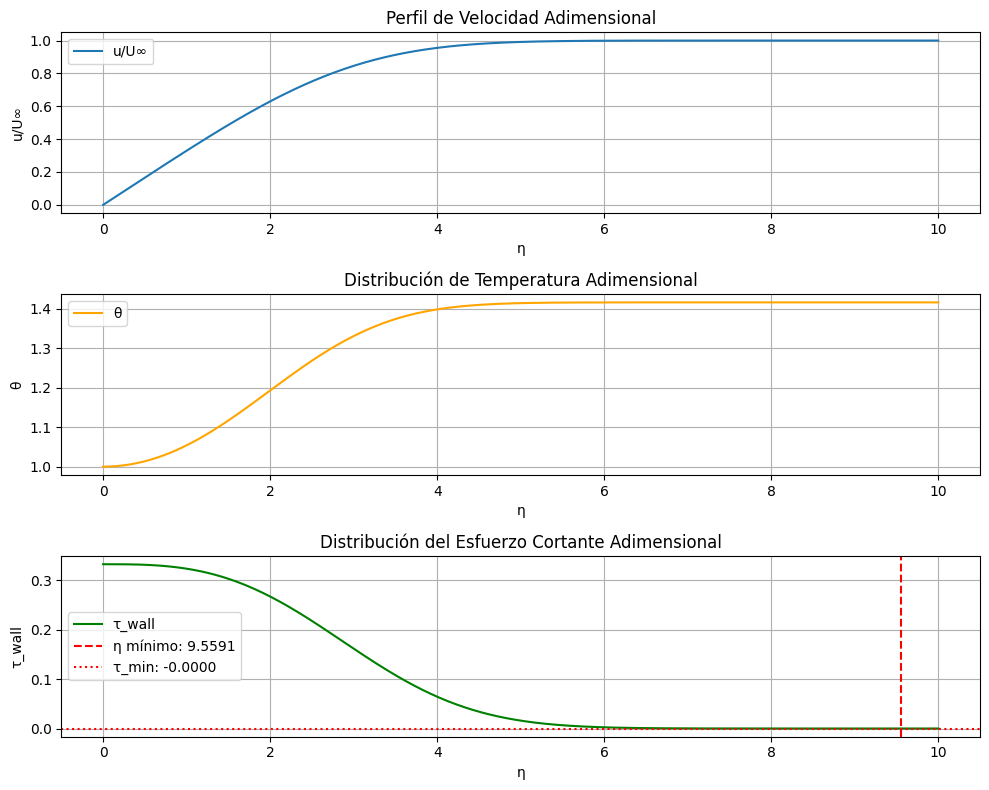

El esfuerzo cortante alcanza su valor mínimo en η = 9.5591
El valor mínimo del esfuerzo cortante es: -0.0000


In [37]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Las funciones blasius_system, initial_conditions, y solve_blasius permanecen iguales

def find_minimum_shear_stress(eta, f_double_prime):
    # Encontrar el índice del valor mínimo de f_double_prime
    min_index = np.argmin(f_double_prime)
    return eta[min_index], f_double_prime[min_index]

eta, results = solve_blasius()
f = results[0]
f_prime = results[1]
f_double_prime = results[2]
theta = results[3]

# Encontrar el valor de eta donde el shear stress es mínimo
eta_min_shear, min_shear = find_minimum_shear_stress(eta, f_double_prime)

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(eta, f_prime, label="u/U∞")
plt.title("Perfil de Velocidad Adimensional")
plt.xlabel("η")
plt.ylabel("u/U∞")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(eta, theta, label="θ", color="orange")
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("η")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(eta, f_double_prime, label="τ_wall", color="green")
plt.axvline(x=eta_min_shear, color='r', linestyle='--', label=f'η mínimo: {eta_min_shear:.4f}')
plt.axhline(y=min_shear, color='r', linestyle=':', label=f'τ_min: {min_shear:.4f}')
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("η")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"El esfuerzo cortante alcanza su valor mínimo en η = {eta_min_shear:.4f}")
print(f"El valor mínimo del esfuerzo cortante es: {min_shear:.4f}")


Este código hace lo siguiente:

1. Define una función `find_extremum` que encuentra el valor máximo o mínimo de los datos y el valor correspondiente de η.

2. Calcula los valores máximos de velocidad y temperatura, y el valor mínimo del esfuerzo cortante, junto con sus correspondientes valores de η.

3. Modifica los gráficos para mostrar líneas verticales en los valores de η donde se alcanzan los extremos y líneas horizontales en los valores extremos.

4. Imprime los resultados para velocidad, temperatura y esfuerzo cortante.

Este enfoque te permitirá visualizar y cuantificar los puntos donde la velocidad y la temperatura alcanzan sus valores máximos, y donde el esfuerzo cortante alcanza su valor mínimo en la solución numérica de la ecuación de Blasius.

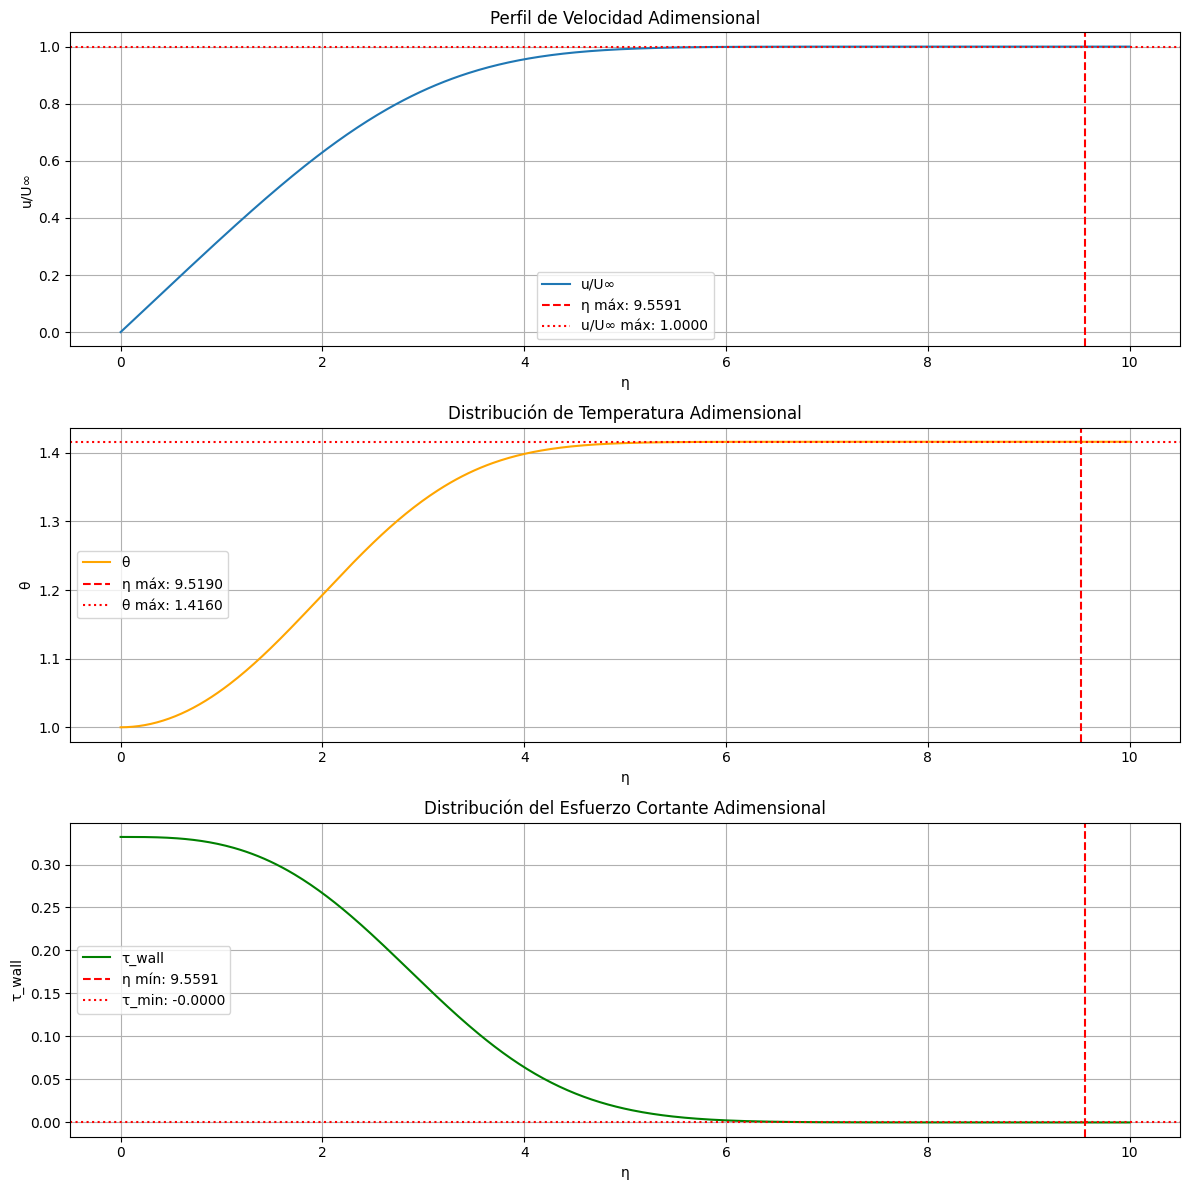

La velocidad alcanza su valor máximo en η = 9.5591
El valor máximo de la velocidad es: 1.0000
La temperatura alcanza su valor máximo en η = 9.5190
El valor máximo de la temperatura es: 1.4160
El esfuerzo cortante alcanza su valor mínimo en η = 9.5591
El valor mínimo del esfuerzo cortante es: -0.0000


In [38]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Las funciones blasius_system, initial_conditions, y solve_blasius permanecen iguales

def find_extremum(eta, data, find_max=True):
    if find_max:
        extremum_index = np.argmax(data)
    else:
        extremum_index = np.argmin(data)
    return eta[extremum_index], data[extremum_index]

eta, results = solve_blasius()
f = results[0]
f_prime = results[1]
f_double_prime = results[2]
theta = results[3]

# Encontrar los valores extremos
eta_max_velocity, max_velocity = find_extremum(eta, f_prime)
eta_max_temp, max_temp = find_extremum(eta, theta)
eta_min_shear, min_shear = find_extremum(eta, f_double_prime, find_max=False)

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1)
plt.plot(eta, f_prime, label="u/U∞")
plt.axvline(x=eta_max_velocity, color='r', linestyle='--', label=f'η máx: {eta_max_velocity:.4f}')
plt.axhline(y=max_velocity, color='r', linestyle=':', label=f'u/U∞ máx: {max_velocity:.4f}')
plt.title("Perfil de Velocidad Adimensional")
plt.xlabel("η")
plt.ylabel("u/U∞")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(eta, theta, label="θ", color="orange")
plt.axvline(x=eta_max_temp, color='r', linestyle='--', label=f'η máx: {eta_max_temp:.4f}')
plt.axhline(y=max_temp, color='r', linestyle=':', label=f'θ máx: {max_temp:.4f}')
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("η")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(eta, f_double_prime, label="τ_wall", color="green")
plt.axvline(x=eta_min_shear, color='r', linestyle='--', label=f'η mín: {eta_min_shear:.4f}')
plt.axhline(y=min_shear, color='r', linestyle=':', label=f'τ_min: {min_shear:.4f}')
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("η")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"La velocidad alcanza su valor máximo en η = {eta_max_velocity:.4f}")
print(f"El valor máximo de la velocidad es: {max_velocity:.4f}")
print(f"La temperatura alcanza su valor máximo en η = {eta_max_temp:.4f}")
print(f"El valor máximo de la temperatura es: {max_temp:.4f}")
print(f"El esfuerzo cortante alcanza su valor mínimo en η = {eta_min_shear:.4f}")
print(f"El valor mínimo del esfuerzo cortante es: {min_shear:.4f}")


Ahora me gustaría estudiar la solución transitoria considerando que la dependecia temporal se pierde una vez el sistema evoluciona hasta llegar al estado estacionario. Por tanto, puedo estudiar la evolución temporal inversa. Comenzar desde la solución transitoria y calcular los valores de velocidad, temperatura ($\theta$) y shear stress (que se obtiene con las variaciones de velocidad). Me centro en estos valores porque son los que en principio usaré para el DA.

---
---

## Redefinición del problema de Blasius

Quiero adimensionalizar todo, asi que difino el problema de Blasius como:

Defino mi variable de similitud como:

$$ 
\xi = \Lambda^{-1} \frac{\sigma}{\sqrt{\eta}}
$$

La función de corriente:

$$ 
\varphi = f(\xi)
$$

Las componentes de la velocidad:

$$
u_\eta = \frac{1}{H} f'(\xi) \partial_\sigma \xi
$$
$$
u_\sigma = - \frac{1}{L} f'(\xi) \partial_\eta \xi
$$

La ecuación e Blasius (Ecuación de Navier-Stokes):

$$
\Lambda^{-1} \left[f'''(\xi) + f(\xi) f'(\xi)\right] + \frac{\sigma}{\eta}\left[1 - f'(\xi)^2\right] = 0
$$

Condiciones de contorno:

$$
\left(\sigma = 0, \xi = 0\right): f(0) = 0, f'(0) = 0
$$
$$
\left(\sigma = 1, \xi = \frac{1}{\Lambda}\right): f(\frac{1}{\Lambda}) = 1
$$

- Ecuación de la energía:

$$
u_\eta \partial_\eta \theta + \Lambda u_\sigma \partial_\sigma \theta = \frac{\Lambda^2}{Re} \left( \frac{1}{Pr} \partial_\sigma^2 \theta + \frac{1}{\beta} (\partial_\sigma u_\eta)^2 \right) 
$$

- Parámetros adimensionales

$ \eta = \frac{x}{L} $
$ \sigma = \frac{y}{H} $
$ \theta = \frac{h - h_{ref}}{h_{max} - h_{ref}} $
$ u_\eta = \frac{u_x}{u_\infty} $
$ u_\sigma = \frac{u_y}{u_\infty} $
$ \Lambda = \frac{L}{H} $
$ Re = \frac{\rho u_\infty L}{\mu} $
$ Pr = \frac{\mu c_p}{k}$
$ \beta = \frac{h_{max} - h_{ref}}{u_\infty^2} $



/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2914/3280102503.py:81: RuntimeWarning: divide by zero encountered in divide
  u_sigma = -Lambda * f_prime * xi / (2 * np.sqrt(1 - Lambda**2 * xi**2))


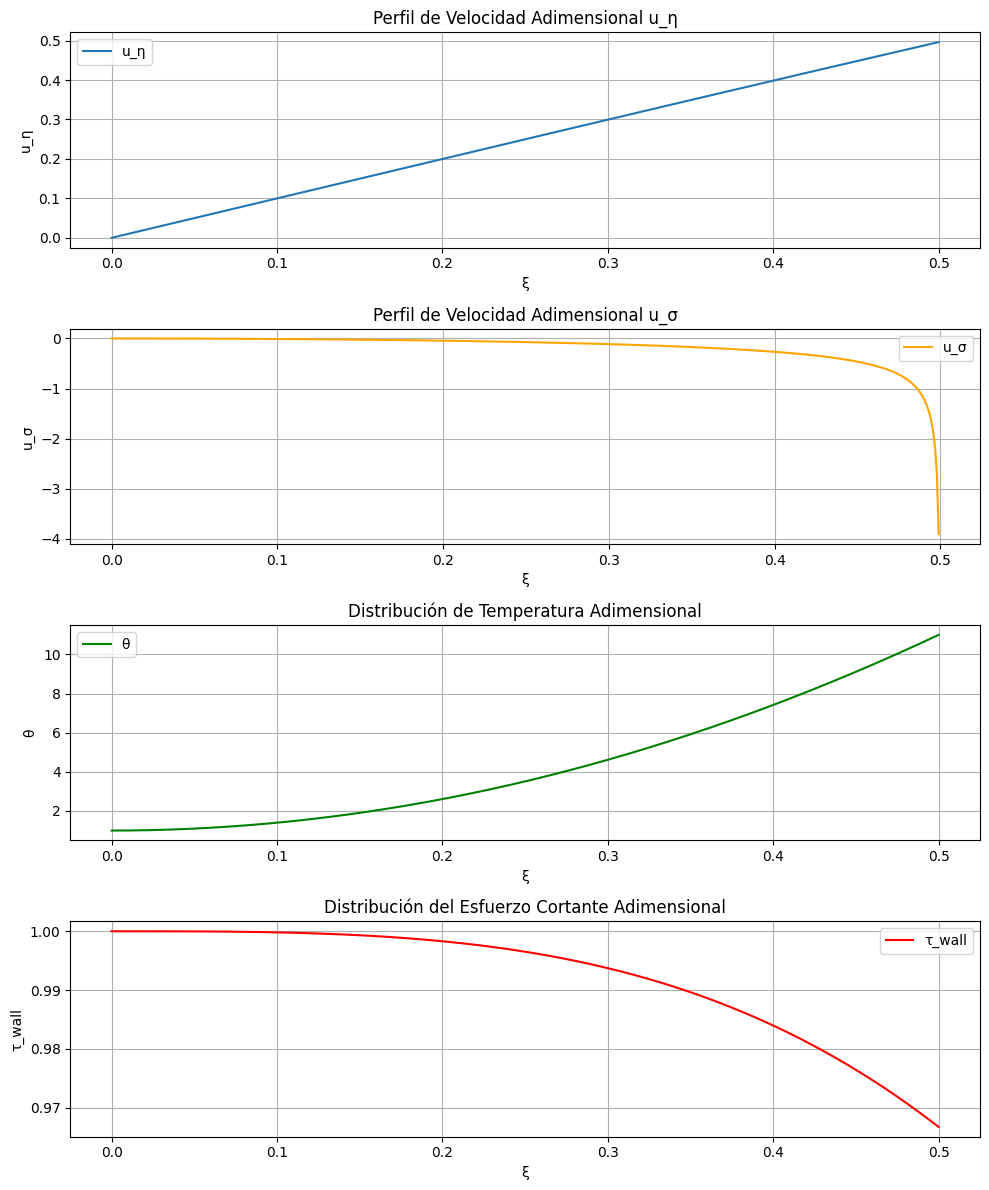

Valor final de f(1/Λ): 0.12462826199209122
Valor final de f'(1/Λ): 0.49609797291941965


In [39]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros del problema
rho = 1.225  # Densidad del aire [kg/m³]
u_inf = 100  # Velocidad del aire a la entrada [m/s]
mu = 1.7894e-5  # Viscosidad dinámica del aire [Pa·s]
k = 0.0257  # Conductividad térmica del aire [W/m·K]
cp = 1006  # Capacidad calorífica del aire a presión constante [J/kg·K]
L = 1  # Longitud característica [m]
H = 0.5  # Altura [m]
T_inf = 300  # Temperatura a la entrada [K]
T_max = 350  # Temperatura en la pared [K]

# Cálculo de parámetros derivados
h_max = cp * T_max  # Coeficiente de transferencia de calor en la pared [W/m²·K]
h_inf = cp * T_inf  # Coeficiente de transferencia de calor a la entrada [W/m²·K]
Re = rho * u_inf * L / mu  # Número de Reynolds
Pr = mu * cp / k  # Número de Prandtl
Lambda = L / H  # Relación de aspecto
beta = (h_max - h_inf) / u_inf**2  # Relación para la disipación térmica

def modified_blasius_system(xi, y):
    """
    Sistema de ecuaciones diferenciales para el problema modificado de Blasius con transferencia térmica.
    """
    f, f_prime, f_double_prime, theta, theta_prime = y
    
    # Ecuaciones diferenciales modificadas
    df_dxi = f_prime
    df_prime_dxi = f_double_prime
    df_double_prime_dxi = -Lambda * (f * f_prime + (xi**2 / Lambda**2) * (1 - f_prime**2))
    dtheta_dxi = theta_prime
    dtheta_prime_dxi = -Pr * Lambda**2 * (f * theta_prime - (xi / Lambda) * f_prime * theta_prime) + beta * Lambda**4 * f_double_prime**2
    
    return [df_dxi, df_prime_dxi, df_double_prime_dxi, dtheta_dxi, dtheta_prime_dxi]

def initial_conditions():
    """
    Condiciones iniciales para el problema modificado.
    """
    return [0.0, 0.0, 1.0, 1.0, 0.0]  # Estimación inicial para f''(0)

def solve_modified_blasius():
    """
    Resuelve las ecuaciones diferenciales del problema modificado de Blasius con transferencia térmica.
    """
    xi_span = (0, 1/Lambda)  # Rango para ξ
    xi_eval = np.linspace(*xi_span, 500)  # Puntos donde evaluar la solución
    
    # Resolver las ecuaciones diferenciales
    sol = solve_ivp(modified_blasius_system, xi_span, initial_conditions(), t_eval=xi_eval, method='RK45')
    
    if sol.success:
        return sol.t, sol.y
    else:
        raise RuntimeError("No se pudo resolver el sistema modificado.")

# Resolver el sistema modificado
xi, results = solve_modified_blasius()
f = results[0]
f_prime = results[1]
f_double_prime = results[2]
theta = results[3]

# Graficar los resultados
plt.figure(figsize=(10, 12))

# Perfil de velocidad adimensional u_η
plt.subplot(4, 1, 1)
plt.plot(xi, f_prime, label="u_η")
plt.title("Perfil de Velocidad Adimensional u_η")
plt.xlabel("ξ")
plt.ylabel("u_η")
plt.grid(True)
plt.legend()

# Perfil de velocidad adimensional u_σ
plt.subplot(4, 1, 2)
u_sigma = -Lambda * f_prime * xi / (2 * np.sqrt(1 - Lambda**2 * xi**2))
plt.plot(xi, u_sigma, label="u_σ", color="orange")
plt.title("Perfil de Velocidad Adimensional u_σ")
plt.xlabel("ξ")
plt.ylabel("u_σ")
plt.grid(True)
plt.legend()

# Distribución de temperatura θ
plt.subplot(4, 1, 3)
plt.plot(xi, theta, label="θ", color="green")
plt.title("Distribución de Temperatura Adimensional")
plt.xlabel("ξ")
plt.ylabel("θ")
plt.grid(True)
plt.legend()

# Distribución del esfuerzo cortante τ_wall (proporcional a f''(ξ))
plt.subplot(4, 1, 4)
plt.plot(xi, f_double_prime, label="τ_wall", color="red")
plt.title("Distribución del Esfuerzo Cortante Adimensional")
plt.xlabel("ξ")
plt.ylabel("τ_wall")
plt.grid(True)
plt.legend()

# Mostrar gráficos
plt.tight_layout()
plt.show()

# Imprimir valores finales
print(f"Valor final de f(1/Λ): {f[-1]}")
print(f"Valor final de f'(1/Λ): {f_prime[-1]}")


---
---

## Blasius normal

Se asume que los perfiles de velocidad y temperatura pueden expresarse en términos de una variable de similitud $\eta$, combinando las coordenadas $x$ e $y$:
$ \eta = y \sqrt{\frac{u_\infty}{\nu x}}, $
donde $\nu = \mu/\rho$ es la viscosidad cinemática.

#### **Transformación clave**:
- Se introduce la **función de corriente** $f(\eta)$:
  $$ u_x = u_\infty f'(\eta), \quad u_y = \frac{1}{2} \sqrt{\frac{\nu u_\infty}{x}} (\eta f' - f) $$

- La ecuación de momento se reduce a:

  $$ f''' + \frac{1}{2} f f'' = 0, $$
  con condiciones:
  $$ f(0) = 0, \quad f'(0) = 0, \quad f'(\infty) = 1. $$

---

<!--

## Blasius adimensional simple (sin meter nada de temperatura)

Defino mi variable de similitud como:

$$ 
\xi = \Lambda^{-1} \frac{\sigma}{\sqrt{\eta}}
$$

La función de corriente:

$$ 
\varphi = f(\xi)
$$

Las componentes de la velocidad:

$$
u_\eta = \frac{1}{H} f'(\xi) \partial_\sigma \xi
$$
$$
u_\sigma = - \frac{1}{L} f'(\xi) \partial_\eta \xi
$$

La ecuación e Blasius (Ecuación de Navier-Stokes):

$$
\Lambda^{-1} \left[f'''(\xi) + f(\xi) f'(\xi)\right] + \frac{\sigma}{\eta}\left[1 - f'(\xi)^2\right] = 0
$$

Condiciones de contorno:

$$
\left(\sigma = 0, \xi = 0\right): f(0) = 0, f'(0) = 0
$$
$$
\left(\sigma = 1, \xi = \frac{1}{\Lambda}\right): f(\frac{1}{\Lambda}) = 1
$$


- Parámetro adimensionales

$ \Lambda = \frac{L}{H} $

-->

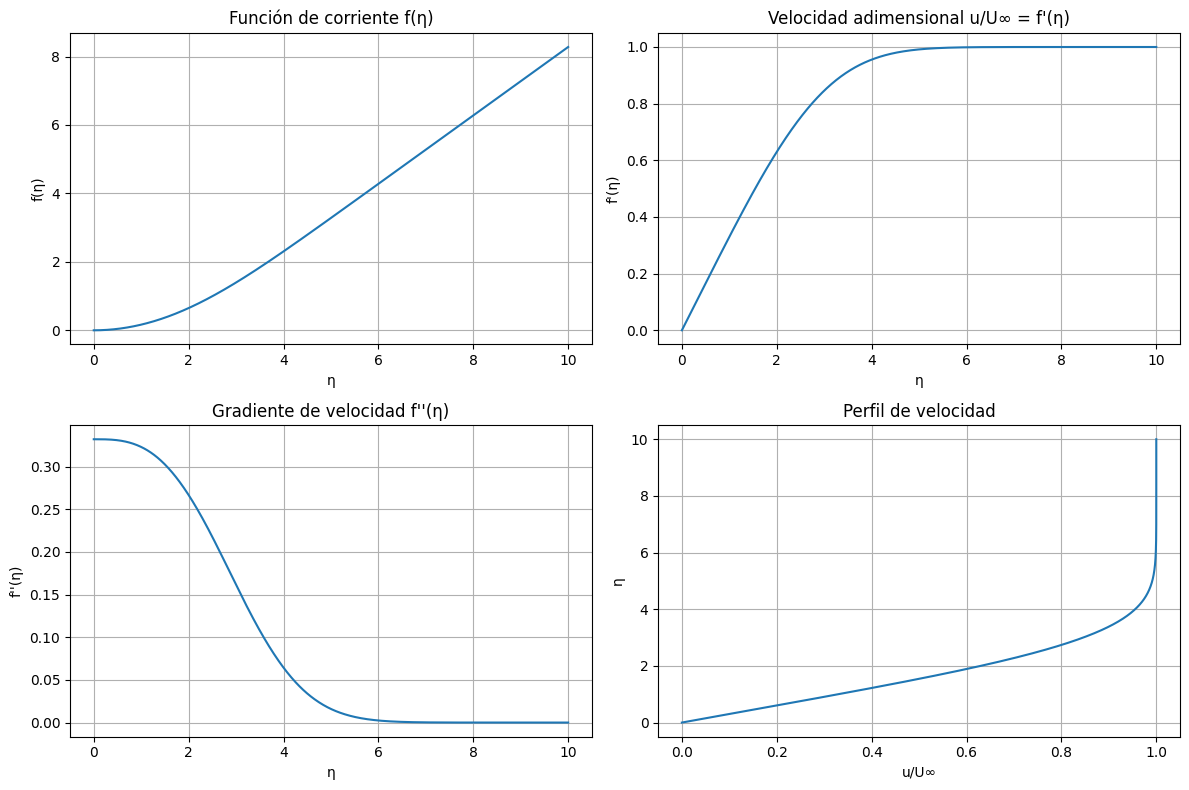

f''(0) ≈ 0.332000
δ99/x ≈ 6.950739


In [40]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def blasius_equation(eta, y):
    """
    Sistema de ecuaciones diferenciales para el problema de Blasius.
    y[0] = f
    y[1] = f'
    y[2] = f''
    """
    return [
        y[1],
        y[2],
        -0.5 * y[0] * y[2]
    ]

def solve_blasius():
    """
    Resuelve la ecuación de Blasius usando el método de disparo.
    """
    eta_max = 10  # Valor máximo de eta (considerado como "infinito")
    eta_span = (0, eta_max)
    
    # Condiciones iniciales
    # f(0) = 0, f'(0) = 0, f''(0) es desconocido (usamos un valor inicial estimado)
    y0 = [0, 0, 0.332]  # El valor 0.332 es una estimación inicial para f''(0)
    
    # Resolver la ecuación diferencial
    sol = solve_ivp(blasius_equation, eta_span, y0, dense_output=True)
    
    # Crear un array de eta para evaluar la solución
    eta = np.linspace(0, eta_max, 1000)
    
    # Evaluar la solución
    y = sol.sol(eta)
    
    return eta, y

def plot_results(eta, y):
    """
    Grafica los resultados de la solución de Blasius.
    """
    plt.figure(figsize=(12, 8))
    
    # Graficar f
    plt.subplot(2, 2, 1)
    plt.plot(eta, y[0])
    plt.title("Función de corriente f(η)")
    plt.xlabel("η")
    plt.ylabel("f(η)")
    plt.grid(True)
    
    # Graficar f'
    plt.subplot(2, 2, 2)
    plt.plot(eta, y[1])
    plt.title("Velocidad adimensional u/U∞ = f'(η)")
    plt.xlabel("η")
    plt.ylabel("f'(η)")
    plt.grid(True)
    
    # Graficar f''
    plt.subplot(2, 2, 3)
    plt.plot(eta, y[2])
    plt.title("Gradiente de velocidad f''(η)")
    plt.xlabel("η")
    plt.ylabel("f''(η)")
    plt.grid(True)
    
    # Graficar perfil de velocidad
    plt.subplot(2, 2, 4)
    plt.plot(y[1], eta)
    plt.title("Perfil de velocidad")
    plt.xlabel("u/U∞")
    plt.ylabel("η")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Resolver y graficar
eta, y = solve_blasius()
plot_results(eta, y)

# Imprimir algunos valores de interés
print(f"f''(0) ≈ {y[2][0]:.6f}")
print(f"δ99/x ≈ {eta[np.argmin(abs(y[1] - 0.99))] * np.sqrt(2):.6f}")


Los valores f''(0) y δ99/x son de interés en el problema de Blasius por las siguientes razones:

1. f''(0): Este valor representa el gradiente de velocidad en la pared (y=0). Es proporcional al esfuerzo cortante en la pared, que es crucial para determinar la fuerza de arrastre sobre la placa plana[1].

2. δ99/x: Este valor representa el espesor de la capa límite normalizado por la distancia x desde el borde de ataque de la placa. Específicamente, δ99 es la distancia desde la pared donde la velocidad alcanza el 99% de la velocidad de la corriente libre. Este parámetro es importante para caracterizar el crecimiento de la capa límite a lo largo de la placa[1][3].

Estos valores son útiles para:

- Calcular el coeficiente de fricción superficial
- Estimar la fuerza de arrastre sobre la placa
- Determinar la región afectada por los efectos viscosos
- Comparar con resultados experimentales y otras soluciones teóricas

Para representar gráficamente estos valores, se podría:

1. Graficar f''(η) vs η, destacando el valor de f''(0)
2. Graficar el perfil de velocidad u/U∞ vs η, mostrando δ99
3. Representar δ99/x vs Rex (número de Reynolds basado en x) para ilustrar el crecimiento de la capa límite

Estas representaciones ayudarían a visualizar mejor las características clave de la solución de Blasius para la capa límite laminar.

---

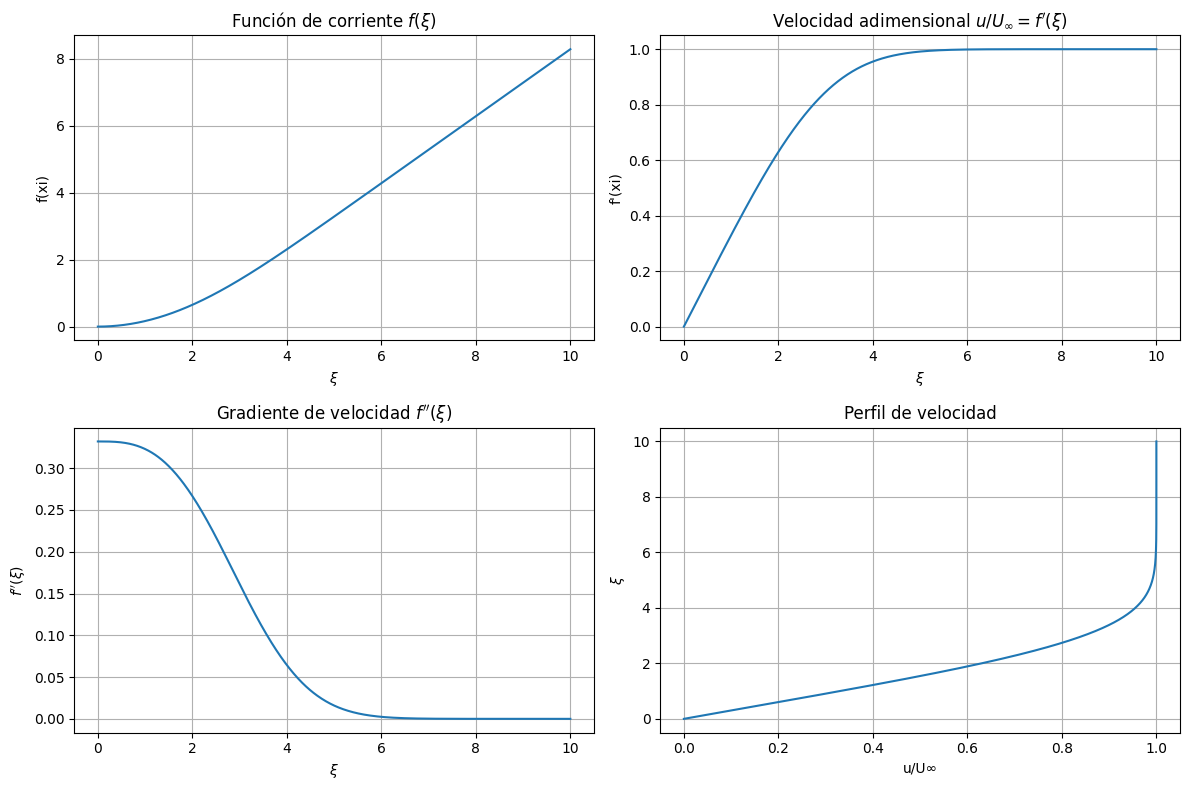

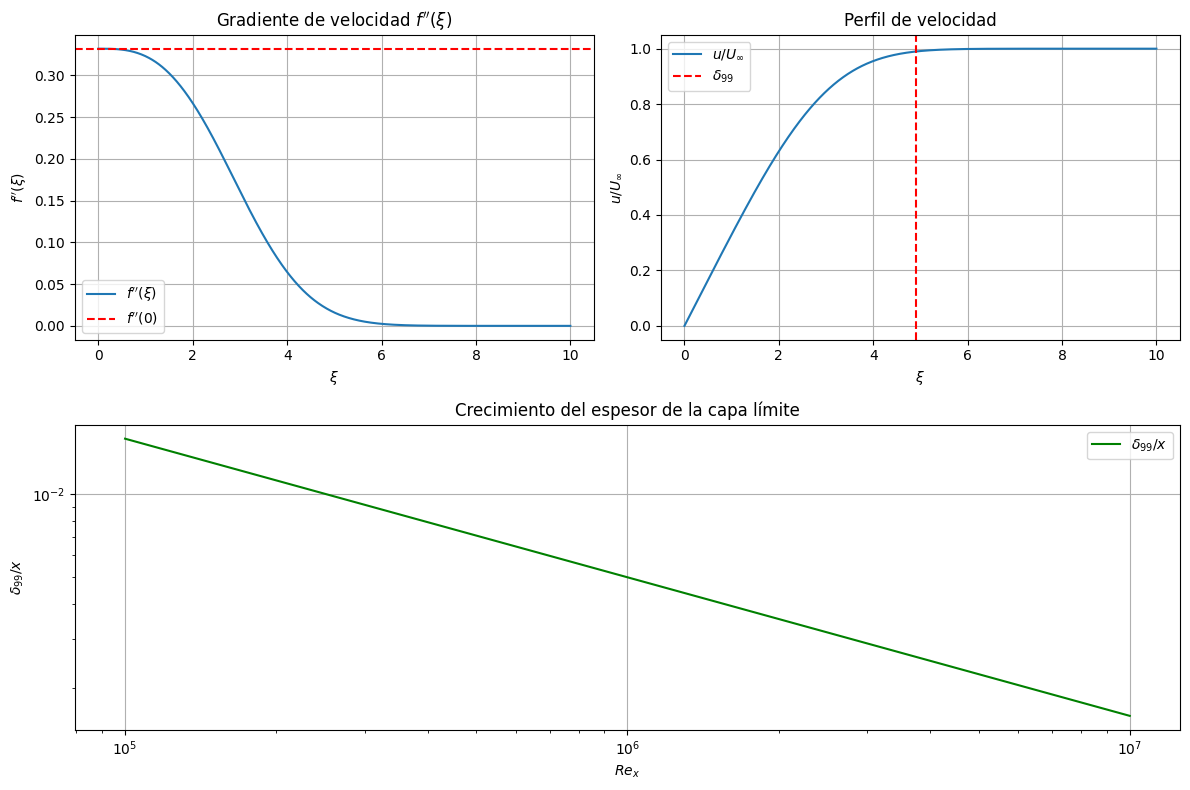

f''(0) ≈ 0.332000
δ99/x ≈ 6.950739


In [41]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def blasius_equation(xi, y):
    """
    Sistema de ecuaciones diferenciales para el problema de Blasius.
    y[0] = f
    y[1] = f'
    y[2] = f''
    """
    return [
        y[1],
        y[2],
        -0.5 * y[0] * y[2]
    ]

def solve_blasius():
    """
    Resuelve la ecuación de Blasius usando el método de disparo.
    """
    xi_max = 10  # Valor máximo de xi (considerado como "infinito")
    xi_span = (0, xi_max)
    
    # Condiciones iniciales
    # f(0) = 0, f'(0) = 0, f''(0) es desconocido (usamos un valor inicial estimado)
    y0 = [0, 0, 0.332]  # El valor 0.332 es una estimación inicial para f''(0)
    
    # Resolver la ecuación diferencial
    sol = solve_ivp(blasius_equation, xi_span, y0, dense_output=True)
    
    # Crear un array de xi para evaluar la solución
    xi = np.linspace(0, xi_max, 1000)
    
    # Evaluar la solución
    y = sol.sol(xi)
    
    return xi, y

def plot_results(xi, y):
    """
    Grafica los resultados de la solución de Blasius.
    """
    plt.figure(figsize=(12, 8))
    
    # Graficar f
    plt.subplot(2, 2, 1)
    plt.plot(xi, y[0])
    plt.title(r"Función de corriente $f(\xi)$")
    plt.xlabel(r'$\xi$')
    plt.ylabel("f(xi)")
    plt.grid(True)
    
    # Graficar f'
    plt.subplot(2, 2, 2)
    plt.plot(xi, y[1])
    plt.title(r"Velocidad adimensional $u/U_\infty = f'(\xi)$")
    plt.xlabel(r'$\xi$')
    plt.ylabel("f'(xi)")
    plt.grid(True)
    
    # Graficar f''
    plt.subplot(2, 2, 3)
    plt.plot(xi, y[2])
    plt.title(r"Gradiente de velocidad $f''(\xi)$")
    plt.xlabel(r'$\xi$')
    plt.ylabel(r"$f''(\xi)$")
    plt.grid(True)
    
    # Graficar perfil de velocidad
    plt.subplot(2, 2, 4)
    plt.plot(y[1], xi)
    plt.title("Perfil de velocidad")
    plt.xlabel("u/U∞")
    plt.ylabel(r'$\xi$')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_additional_results(xi, y, delta_99_over_x):
    """
    Representaciones adicionales para los valores de interés:
    - f''(0): Gradiente de velocidad en la pared.
    - δ99/x: Espesor de la capa límite normalizado.
    - Crecimiento de la capa límite en función del número de Reynolds.
    """
    # Calcular valores de interés
    fpp_0 = y[2][0]  # f''(0)
    
    # Encontrar xi donde f'(xi) ≈ 0.99 (para δ99)
    delta_99_xi = xi[np.argmin(np.abs(y[1] - 0.99))]
    
    # Número de Reynolds basado en x
    Rex = np.linspace(1e5, 1e7, 100)  # Rango típico del número de Reynolds
    delta_99_vs_Rex = 5.0 / np.sqrt(Rex)  # Relación teórica para δ99/x
    
    # Graficar f''(xi) vs xi, destacando f''(0)
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.plot(xi, y[2], label=r"$f''(\xi)$")
    plt.axhline(fpp_0, color="red", linestyle="--", label=r"$f''(0)$")
    plt.title(r"Gradiente de velocidad $f''(\xi)$")
    plt.xlabel(r"$\xi$")
    plt.ylabel(r"$f''(\xi)$")
    plt.legend()
    plt.grid(True)

    # Graficar perfil de velocidad u/U∞ vs xi, destacando δ99
    plt.subplot(2, 2, 2)
    plt.plot(xi, y[1], label=r"$u/U_\infty$")
    plt.axvline(delta_99_xi, color="red", linestyle="--", label=r"$\delta_{99}$")
    plt.title("Perfil de velocidad")
    plt.xlabel(r"$\xi$")
    plt.ylabel(r"$u/U_\infty$")
    plt.legend()
    plt.grid(True)

    # Graficar δ99/x vs Rex
    plt.subplot(2, 1, 2)
    plt.plot(Rex, delta_99_vs_Rex, label=r"$\delta_{99}/x$", color="green")
    plt.title("Crecimiento del espesor de la capa límite")
    plt.xlabel(r"$Re_x$")
    plt.ylabel(r"$\delta_{99}/x$")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid(True)

    # Mostrar todas las gráficas
    plt.tight_layout()
    plt.show()

# Resolver la ecuación de Blasius
xi, y = solve_blasius()

# Calcular delta_99_over_x
delta_99_xi = xi[np.argmin(np.abs(y[1] - 0.99))]
delta_99_over_x = delta_99_xi * np.sqrt(2)

# Graficar resultados básicos
plot_results(xi, y)

# Graficar resultados adicionales
plot_additional_results(xi, y, delta_99_over_x)

# Imprimir valores de interés
print(f"f''(0) ≈ {y[2][0]:.6f}")
print(f"δ99/x ≈ {delta_99_over_x:.6f}")


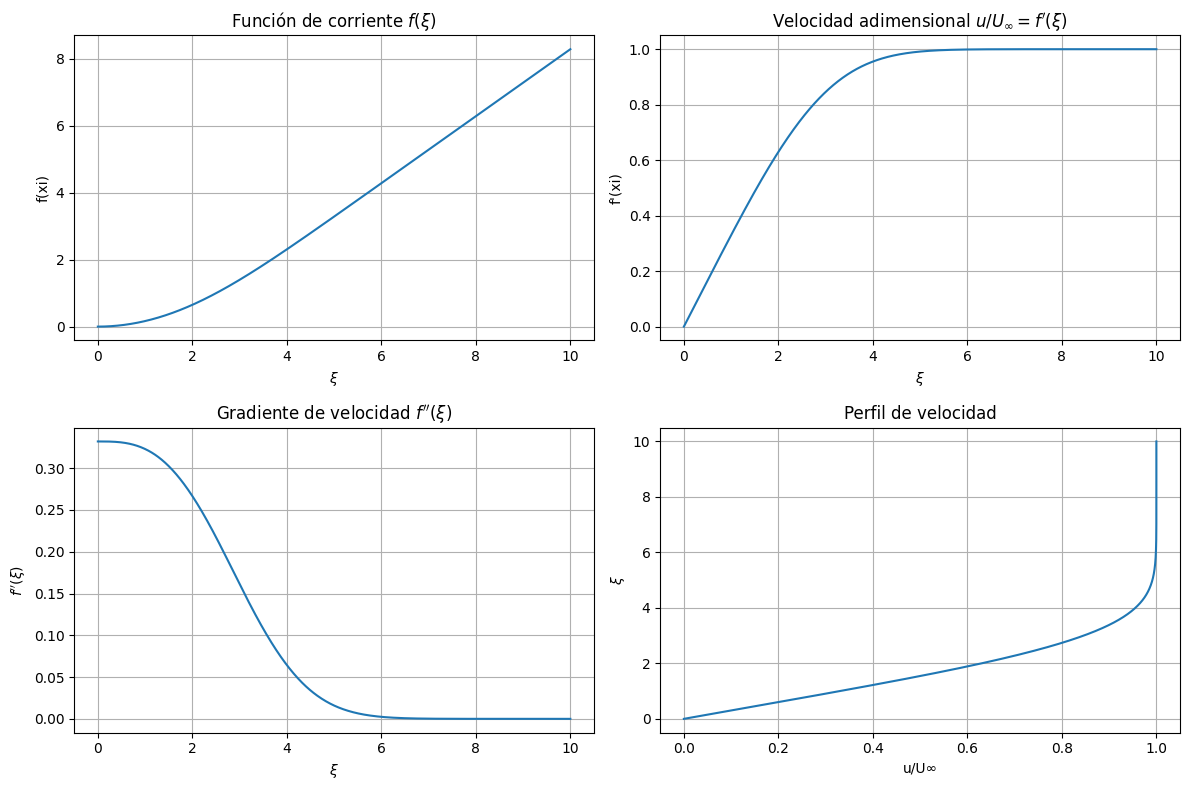

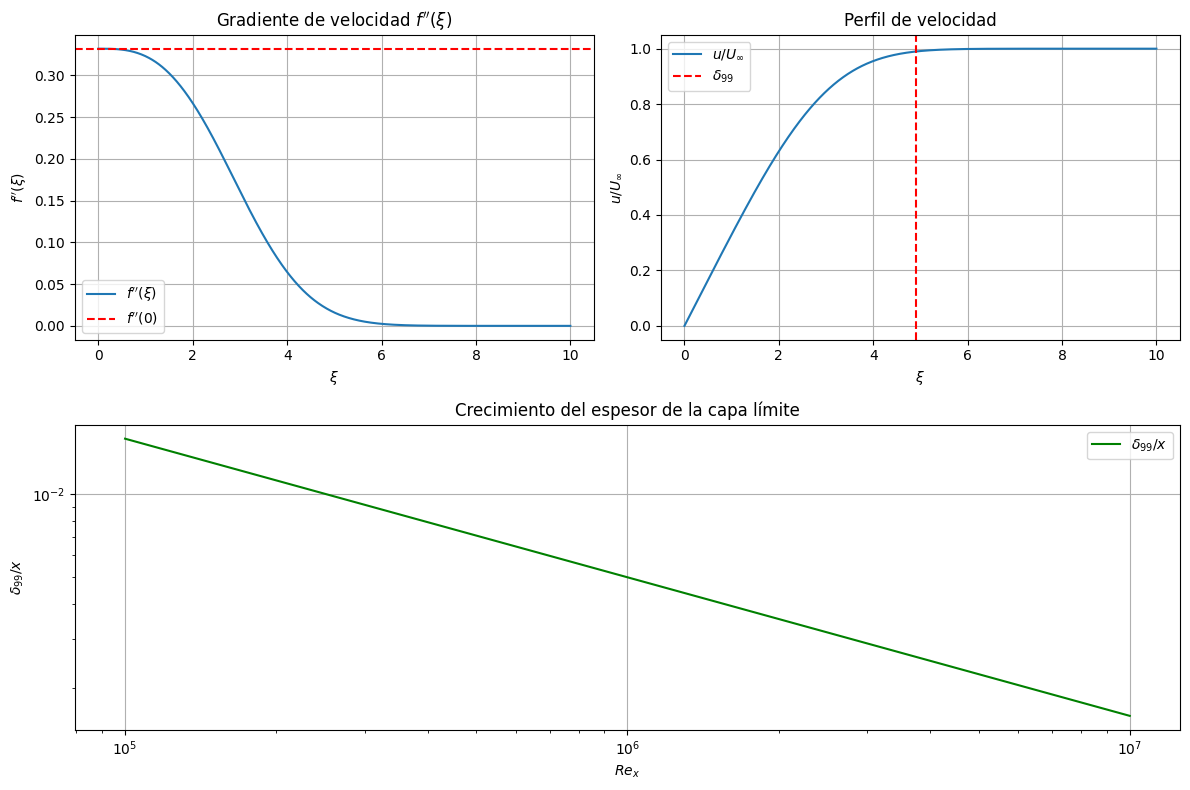

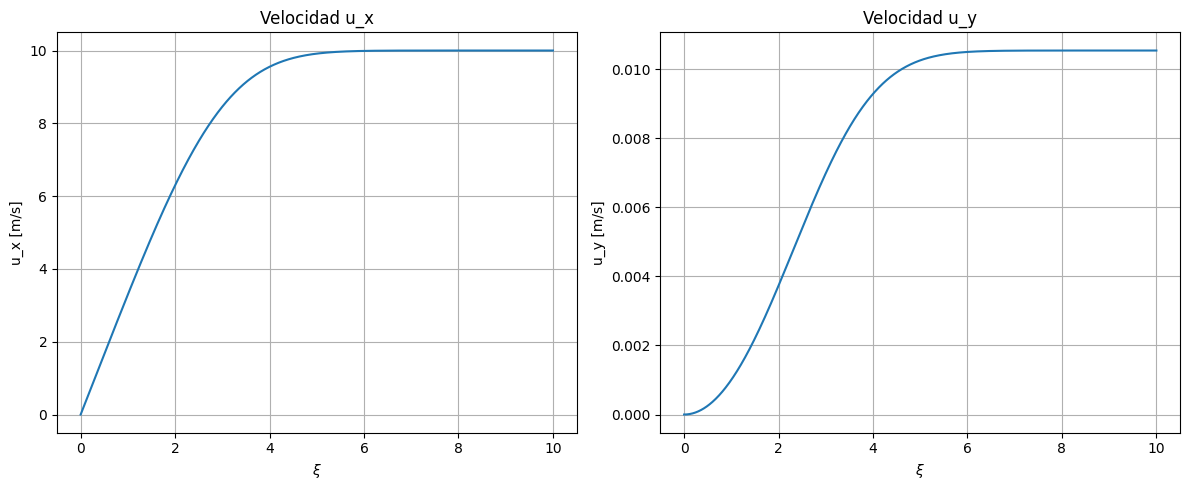

f''(0) ≈ 0.332000
δ99/x ≈ 6.950739


In [42]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros adicionales
u_inf = 10  # Velocidad de corriente libre [m/s]
nu = 1.5e-5  # Viscosidad cinemática [m^2/s]
x = 1.0  # Distancia desde el borde de ataque [m]

def blasius_equation(xi, y):
    return [y[1], y[2], -0.5 * y[0] * y[2]]

def solve_blasius():
    xi_max = 10
    xi_span = (0, xi_max)
    y0 = [0, 0, 0.332]
    sol = solve_ivp(blasius_equation, xi_span, y0, dense_output=True)
    xi = np.linspace(0, xi_max, 1000)
    y = sol.sol(xi)
    return xi, y

'''
def plot_results(xi, y):
    # ... (código anterior para graficar f, f', f'', y perfil de velocidad) ...

def plot_additional_results(xi, y, delta_99_over_x):
    # ... (código anterior para graficar resultados adicionales) ...
'''
def plot_velocities(xi, y):
    """
    Grafica las velocidades u_x y u_y.
    """
    # Calcular u_x y u_y
    u_x = u_inf * y[1]
    u_y = 0.5 * np.sqrt(nu * u_inf / x) * (xi * y[1] - y[0])

    plt.figure(figsize=(12, 5))

    # Graficar u_x
    plt.subplot(1, 2, 1)
    plt.plot(xi, u_x)
    plt.title("Velocidad u_x")
    plt.xlabel(r'$\xi$')
    plt.ylabel("u_x [m/s]")
    plt.grid(True)

    # Graficar u_y
    plt.subplot(1, 2, 2)
    plt.plot(xi, u_y)
    plt.title("Velocidad u_y")
    plt.xlabel(r'$\xi$')
    plt.ylabel("u_y [m/s]")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Resolver la ecuación de Blasius
xi, y = solve_blasius()

# Calcular delta_99_over_x
delta_99_xi = xi[np.argmin(np.abs(y[1] - 0.99))]
delta_99_over_x = delta_99_xi * np.sqrt(2)

# Graficar resultados básicos
plot_results(xi, y)

# Graficar resultados adicionales
plot_additional_results(xi, y, delta_99_over_x)

# Graficar velocidades u_x y u_y
plot_velocities(xi, y)

# Imprimir valores de interés
print(f"f''(0) ≈ {y[2][0]:.6f}")
print(f"δ99/x ≈ {delta_99_over_x:.6f}")


Hasta aquí todo está fenómeno, ahora voy a reescalar los datos:

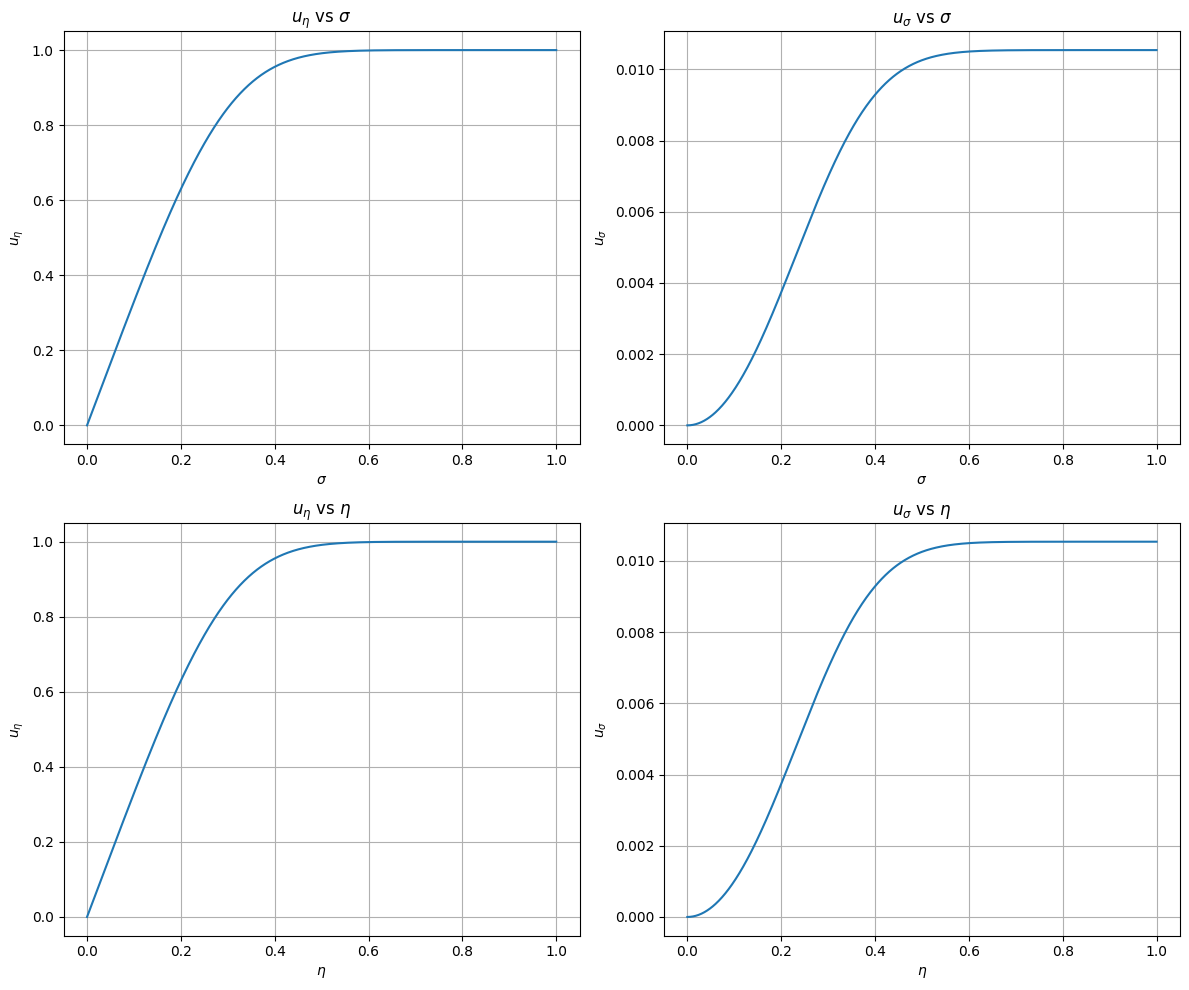

Valor máximo de sigma: 1.000000
Valor máximo de u_sigma: 0.010540


In [47]:
# Parámetros físicos adicionales
u_infty = 10.0  # Velocidad de corriente libre [m/s]
L = 1.0  # Longitud de la placa [m]
ni = 1.5e-5  # Viscosidad cinemática [m^2/s]
H = 10 * np.sqrt(ni * L / u_infty)  # Altura característica [m] esta altura esta determinada por la solución del problema de Blasius

# Calcular las nuevas variables normalizadas
sigma = np.linspace(0, 1, len(eta))
eta_normalized = np.linspace(0, 1, len(eta))  # x/L
u_eta = y[1]  # u_x / u_infty ya está normalizada en la solución de Blasius
u_sigma = 0.5 * (eta * y[1] - y[0]) / np.sqrt(L / (ni * u_infty))  # u_y / u_infty

# Graficar las nuevas variables normalizadas
plt.figure(figsize=(12, 10))

# Graficar u_eta vs sigma
plt.subplot(2, 2, 1)
plt.plot(sigma, u_eta)
plt.title(r'$u_\eta$ vs $\sigma$')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$u_\eta$')
plt.grid(True)

# Graficar u_sigma vs sigma
plt.subplot(2, 2, 2)
plt.plot(sigma, u_sigma)
plt.title(r'$u_\sigma$ vs $\sigma$')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$u_\sigma$')
plt.grid(True)

# Graficar u_eta vs eta_normalized
plt.subplot(2, 2, 3)
plt.plot(eta_normalized, u_eta)
plt.title(r'$u_\eta$ vs $\eta$')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$u_\eta$')
plt.grid(True)

# Graficar u_sigma vs eta_normalized
plt.subplot(2, 2, 4)
plt.plot(eta_normalized, u_sigma)
plt.title(r'$u_\sigma$ vs $\eta$')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$u_\sigma$')
plt.grid(True)

plt.tight_layout()
plt.show()

# Imprimir algunos valores de interés de las nuevas variables
print(f'Valor máximo de sigma: {sigma.max():.6f}')
print(f'Valor máximo de u_sigma: {u_sigma.max():.6f}')


Me ralla que no se verifica la ecuacion de continuidad: $\partial_\eta u_\eta \propto - \partial_\sigma u_\sigma $

---

## Calculo de la distribución de temperatura

- Ecuación de la energía:

$$
u_\eta \partial_\eta \theta + \Lambda u_\sigma \partial_\sigma \theta = \frac{\Lambda^2}{Re} \left( \frac{1}{Pr} \partial_\sigma^2 \theta + \frac{1}{\beta} (\partial_\sigma u_\eta)^2 \right) 
$$

- Parámetros adimensionales

$ \theta = \frac{h - h_{ref}}{h_{max} - h_{ref}} $
$ \Lambda = \frac{L}{H} $
$ Re = \frac{\rho u_\infty L}{\mu} $
$ Pr = \frac{\mu c_p}{k}$
$ \beta = \frac{h_{max} - h_{ref}}{u_\infty^2} $

/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_2914/3785101214.py:49: RuntimeWarning: invalid value encountered in divide
  theta = sigma * (T_max - T_ref) / (T_max - T_ref)


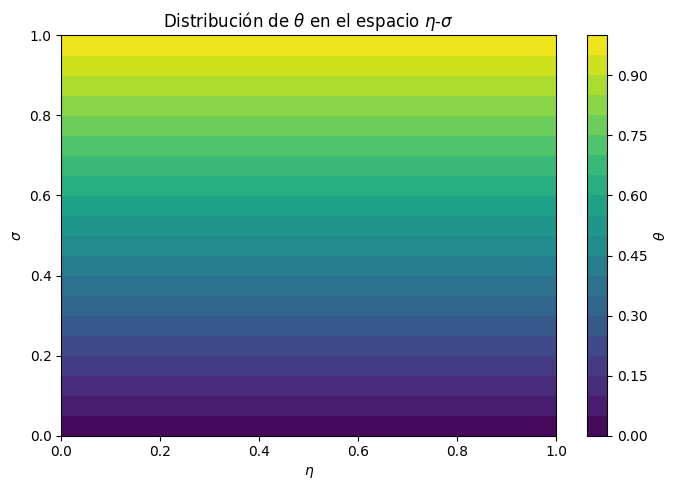

f''(0) ≈ 0.332000
δ99/L ≈ 0.005940
T_max óptimo: 300.10 K
Valor máximo de theta: 1.0000
Valor mínimo de theta: 0.0000


In [56]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parámetros físicos
rho = 1.225  # Densidad del aire [kg/m³]
u_infty = 10.0  # Velocidad de corriente libre [m/s]
L = 1.0  # Longitud de la placa [m]
mu = 1.789e-5  # Viscosidad dinámica del aire [Pa·s]
ni = mu / rho  # Viscosidad cinemática [m^2/s]
cp = 1006  # Capacidad calorífica del aire [J/(kg·K)]
k = 0.0257  # Conductividad térmica del aire [W/(m·K)]
T_ref = 300  # Temperatura de referencia [K]

# Cálculo de parámetros derivados
H = 10 * np.sqrt(ni * L / u_infty)  # Altura característica [m]
Re = rho * u_infty * L / mu
Pr = mu * cp / k
Lambda = L / H

def blasius_equation(eta, y):
    return [y[1], y[2], -0.5 * y[0] * y[2]]

def solve_blasius():
    eta_max = 10
    eta_span = (0, eta_max)
    y0 = [0, 0, 0.332]
    sol = solve_ivp(blasius_equation, eta_span, y0, dense_output=True)
    eta = np.linspace(0, eta_max, 1000)
    y = sol.sol(eta)
    return eta, y

# Resolver la ecuación de Blasius
eta, y = solve_blasius()

# Calcular las nuevas variables normalizadas
sigma = np.linspace(0, 1, len(eta))
eta_normalized = np.linspace(0, 1, len(eta))  # x/L
u_eta = y[1]  # u_x / u_infty ya está normalizada en la solución de Blasius
u_sigma = 0.5 * (eta * y[1] - y[0]) / np.sqrt(L / (ni * u_infty))  # u_y / u_infty

# Función para calcular theta
def calc_theta(T_max):
    h_ref = cp * T_ref
    h_max = cp * T_max
    beta = (h_max - h_ref) / (u_infty**2)
    
    # Simplificación: asumimos que theta varía linealmente con sigma
    theta = sigma * (T_max - T_ref) / (T_max - T_ref)
    return theta, beta

# Función para encontrar T_max que escala theta entre 0 y 1
def find_T_max():
    T_max = T_ref
    while True:
        theta, _ = calc_theta(T_max)
        if np.max(theta) >= 0.99:
            return T_max
        T_max += 0.1

# Encontrar T_max óptimo
T_max_optimal = find_T_max()

# Recalcular theta con T_max óptimo
theta_optimal, beta_optimal = calc_theta(T_max_optimal)

# Crear malla para eta y sigma
eta_mesh, sigma_mesh = np.meshgrid(eta_normalized, sigma)

# Calcular theta_optimal en la malla 2D
theta_optimal_2d = np.zeros_like(eta_mesh)
for i in range(eta_mesh.shape[0]):
    for j in range(eta_mesh.shape[1]):
        theta_optimal_2d[i, j] = (T_max_optimal - T_ref) / (T_max_optimal - T_ref) * sigma_mesh[i, j]

# Graficar la distribución de theta en el espacio eta, sigma
plt.figure(figsize=(7, 5))

contour = plt.contourf(eta_mesh, sigma_mesh, theta_optimal_2d, levels=20, cmap='viridis')
plt.colorbar(contour, label=r'$\theta$')
plt.title(r'Distribución de $\theta$ en el espacio $\eta$-$\sigma$')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\sigma$')

plt.tight_layout()
plt.show()

# Imprimir valores de interés
print(f"f''(0) ≈ {y[2][0]:.6f}")
print(f"δ99/L ≈ {eta[np.argmin(np.abs(y[1] - 0.99))] * np.sqrt(ni * L / u_infty) / L:.6f}")
print(f"T_max óptimo: {T_max_optimal:.2f} K")
print(f"Valor máximo de theta: {np.max(theta_optimal_2d):.4f}")
print(f"Valor mínimo de theta: {np.min(theta_optimal_2d):.4f}")